In [50]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.preprocessing import LabelEncoder

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [51]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

2. DESCRIPTIVE STATISTIK  

2.1 Statistische Zusammenfassung aller Variablen

In [52]:
df.describe(include="all")

,datum,marke,modell,preis_euro,verkaufszahl,kraftstoff,getriebe,hubraum_l,bundesland,kundenzufriedenheit,jahr,monat,wochentag
count,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200
unique,568,5,20,NaN,NaN,4,2,NaN,6,NaN,NaN,NaN,7
top,2024-07-01,Volkswagen,E-Klasse,NaN,NaN,Elektro,Manuell,NaN,Bayern,NaN,NaN,NaN,Monday
freq,6,255,75,NaN,NaN,483,622,NaN,225,NaN,NaN,NaN,196
mean,NaN,NaN,NaN,60453.470833,5.035000,NaN,NaN,1.450000,NaN,4.021583,2024.542500,6.582500,NaN
std,NaN,NaN,NaN,25948.390215,2.537546,NaN,NaN,1.378822,NaN,0.586184,0.498398,3.341032,NaN
min,NaN,NaN,NaN,18086.000000,1.000000,NaN,NaN,0.000000,NaN,3.000000,2024.000000,1.000000,NaN
25%,NaN,NaN,NaN,40274.000000,3.000000,NaN,NaN,0.000000,NaN,3.500000,2024.000000,4.000000,NaN
50%,NaN,NaN,NaN,56129.500000,5.000000,NaN,NaN,1.600000,NaN,4.000000,2025.000000,7.000000,NaN
75%,NaN,NaN,NaN,80027.500000,7.000000,NaN,NaN,2.000000,NaN,4.500000,2025.000000,9.000000,NaN


In [53]:
df.describe()

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,60453.470833,5.035000,1.450000,4.021583,2024.542500,6.582500
std,25948.390215,2.537546,1.378822,0.586184,0.498398,3.341032
min,18086.000000,1.000000,0.000000,3.000000,2024.000000,1.000000
25%,40274.000000,3.000000,0.000000,3.500000,2024.000000,4.000000
50%,56129.500000,5.000000,1.600000,4.000000,2025.000000,7.000000
75%,80027.500000,7.000000,2.000000,4.500000,2025.000000,9.000000
max,124965.000000,9.000000,4.000000,5.000000,2025.000000,12.000000


2.2 Numerische und Kategorische Variablen 

In [54]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat"
]

categorical_columns = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

print(numerical_columns)
print(categorical_columns)

['preis_euro', 'verkaufszahl', 'hubraum_l', 'kundenzufriedenheit', 'jahr', 'monat']
['marke', 'modell', 'kraftstoff', 'getriebe', 'bundesland', 'wochentag']


2.3 Deskriptive Statistik (Variable Teilung) 

In [55]:
# Mittelwert
print("--- Mittelwert ---")
display(df[numerical_columns].mean())

# Median
print("\n--- Median ---")
display(df[numerical_columns].median())

# Quartile
print("\n--- Quartile ---")
display(df[numerical_columns].quantile([0.25, 0.50, 0.75]))

# Standardabweichung
print("\n--- Standardabweichung ---")
display(df[numerical_columns].std())

# Varianz
print("\n--- Varianz ---")
display(df[numerical_columns].var())

# Min / Max
print("\n--- Min / Max ---")
display(df[numerical_columns].agg(["min", "max"]))

--- Mittelwert ---


preis_euro             60453.470833
verkaufszahl               5.035000
hubraum_l                  1.450000
kundenzufriedenheit        4.021583
jahr                    2024.542500
monat                      6.582500
dtype: float64


--- Median ---


preis_euro             56129.5
verkaufszahl               5.0
hubraum_l                  1.6
kundenzufriedenheit        4.0
jahr                    2025.0
monat                      7.0
dtype: float64


--- Quartile ---


...

preis_euro             25948.390215
verkaufszahl               2.537546
hubraum_l                  1.378822
kundenzufriedenheit        0.586184
jahr                       0.498398
monat                      3.341032
dtype: float64


--- Varianz ---


preis_euro             6.733190e+08
verkaufszahl           6.439141e+00
hubraum_l              1.901151e+00
kundenzufriedenheit    3.436122e-01
jahr                   2.484008e-01
monat                  1.116250e+01
dtype: float64


--- Min / Max ---


,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
min,18086,1,0.0,3.0,2024,1
max,124965,9,4.0,5.0,2025,12


3. FEHLENDE WERTE

In [56]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing

,Missing Values,Percentage
datum,0,0.0
marke,0,0.0
modell,0,0.0
preis_euro,0,0.0
verkaufszahl,0,0.0
kraftstoff,0,0.0
getriebe,0,0.0
hubraum_l,0,0.0
bundesland,0,0.0
kundenzufriedenheit,0,0.0


4. DUPLIKATE

In [57]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates}"
)

Duplicate rows: 0


5. DATA VISUALIZATION  - NUMERISCHE ANALYSE 

5.1 Preisverteilung

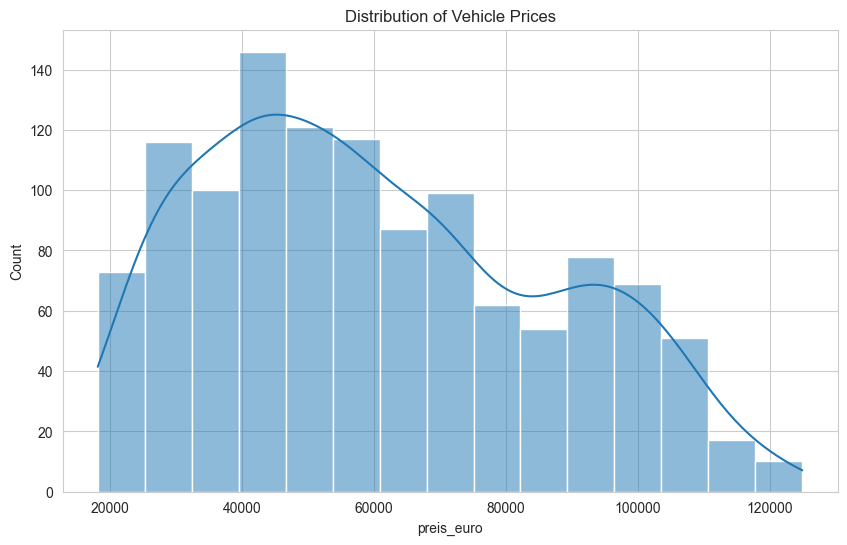

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["preis_euro"],
    kde=True
)

plt.title(
    "Distribution of Vehicle Prices"
)

plt.show()

In [59]:
df["preis_euro"].skew()

np.float64(0.39752956110953036)

Wichtigste Erkenntnisse:  
Schiefe (Skewness): Das Diagramm ist rechtsschief (positiv schief). Dies ist typisch für den Automarkt: Es gibt viele Fahrzeuge im mittleren Preissegment (30.000 – 60.000 Euro), aber je höher der Preis steigt (Richtung 120.000 Euro), desto weniger Autos gibt es.

Spitzenwerte (Modus): Der Hauptpeak liegt bei ca. 40.000 – 45.000 Euro (über 140 Fahrzeuge). Es gibt jedoch einen zweiten, kleineren Peak bei etwa 95.000 Euro. Dies deutet auf zwei verschiedene Marktsegmente hin (z. B. Standard- vs. Premium-Fahrzeuge).

5.2 Verkaufszahlen

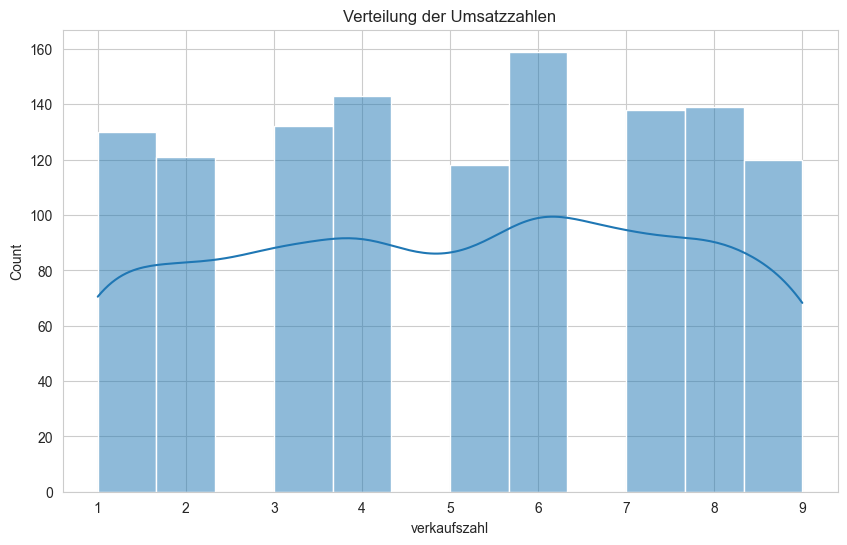

In [60]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["verkaufszahl"],
    kde=True
)

plt.title(
    "Verteilung der Umsatzzahlen"
)

plt.show()

Wichtigste Erkenntnisse:  
Gleichmäßige Verteilung: Insgesamt sind die Daten relativ gleichmäßig verteilt (Gleichverteilung). Es gibt keine extremen Ausreißer oder starken Verzerrungen zu einer Seite.

Spitzenwerte (Modus): Der häufigste Wert ist die 6 mit fast 160 Nennungen. Der zweithäufigste Wert ist die 4 (ca. 143 Mal).

Die geglättete Linie (KDE): Die blaue Kurve zeigt den allgemeinen Trend. Sie verdeutlicht, dass das Niveau über den gesamten Bereich von 1 bis 9 recht stabil bleibt, mit einem leichten Hochpunkt um den Wert 6 herum.

5.3 Kundenzufriedenheit

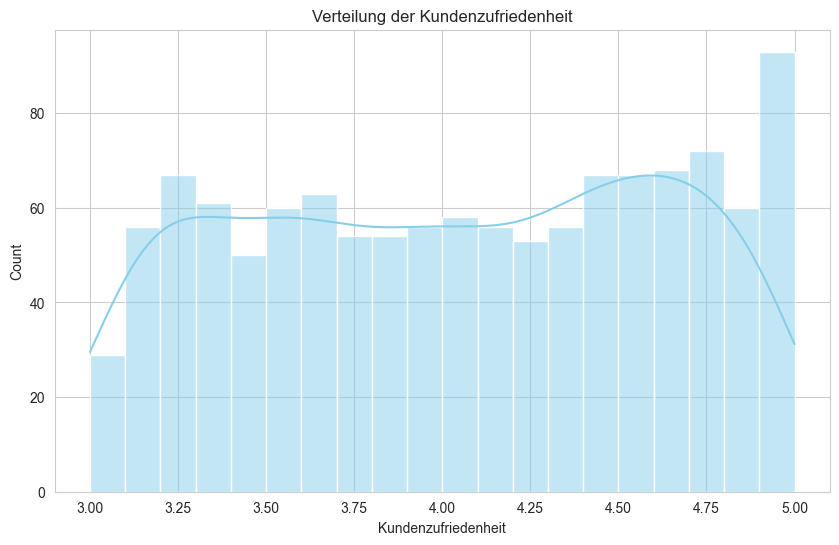

In [61]:
plt.figure(figsize=(10, 6))

sns.histplot(df["kundenzufriedenheit"], kde=True, binwidth=0.1, color="skyblue")

plt.title("Verteilung der Kundenzufriedenheit")
plt.xlabel("Kundenzufriedenheit")
plt.ylabel("Count")
plt.show()

Wichtigste Erkenntnis:  
 Der absolute Spitzenwert (Modus) liegt exakt bei 5,00 (Bestbewertung). Das ist ein typisches Phänomen bei Umfragen – Kunden vergeben sehr gerne die volle Punktzahl.

Fazit für ML: Die Daten sind jetzt sauber und frei von künstlichem Rauschen. Ein ML-Modell kann nun den echten Trend lernen: Die Wahrscheinlichkeit für eine Bewertung über 4,5 ist deutlich höher als für einen Wert um 3,0.

5.4 Ausreisseranalyse

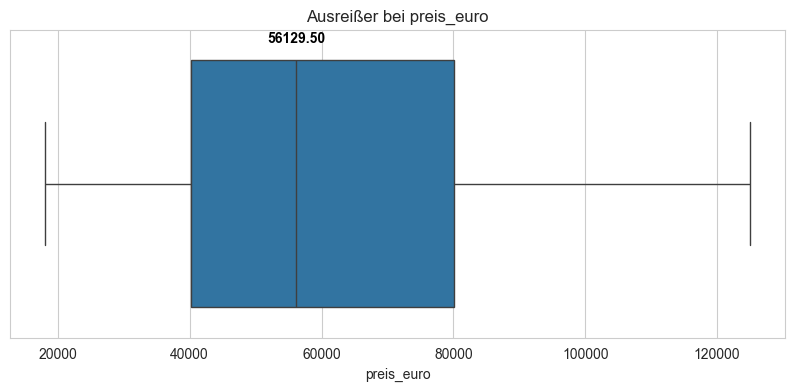

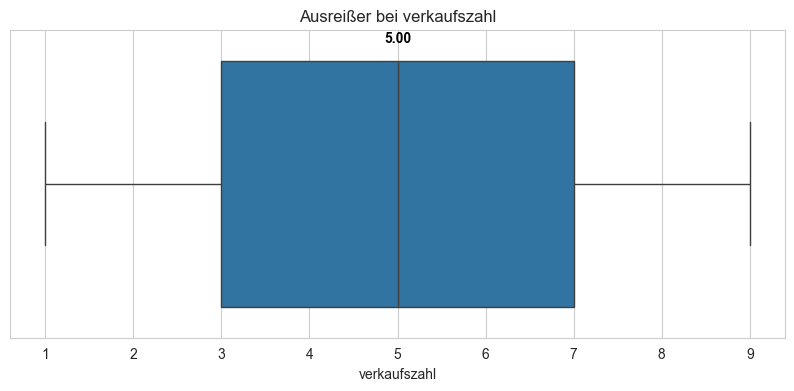

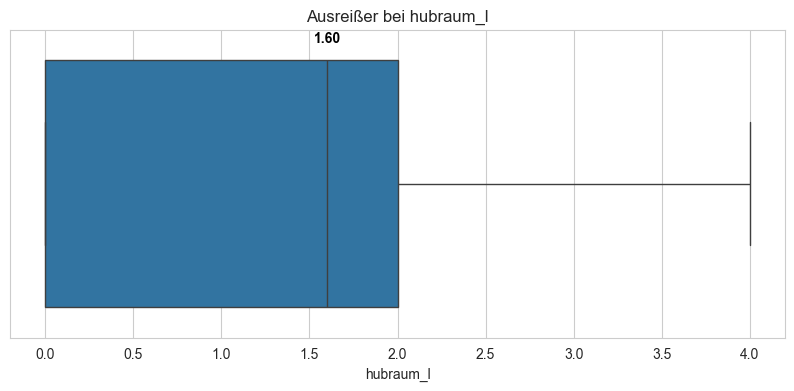

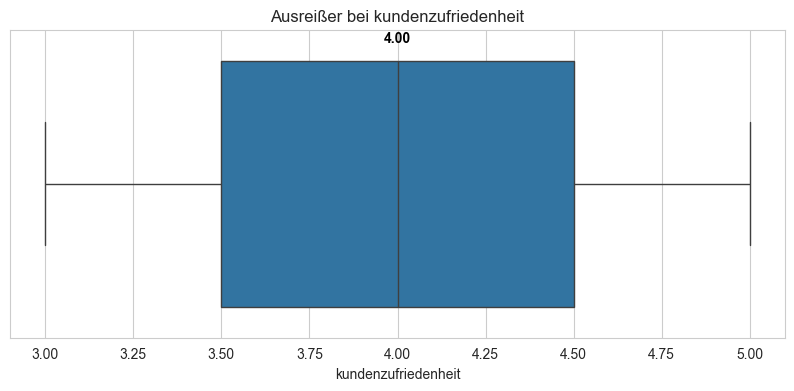

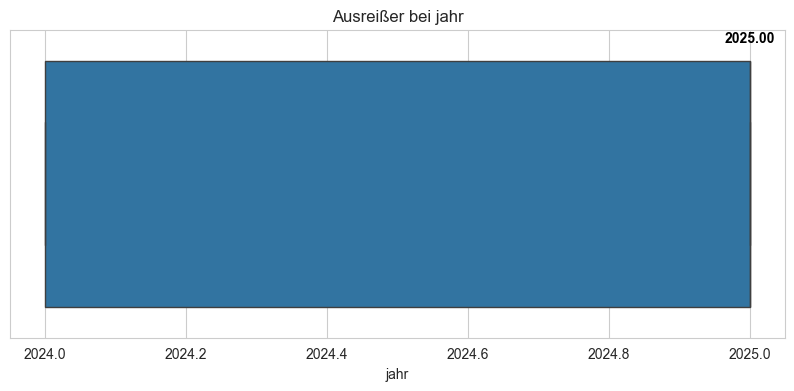

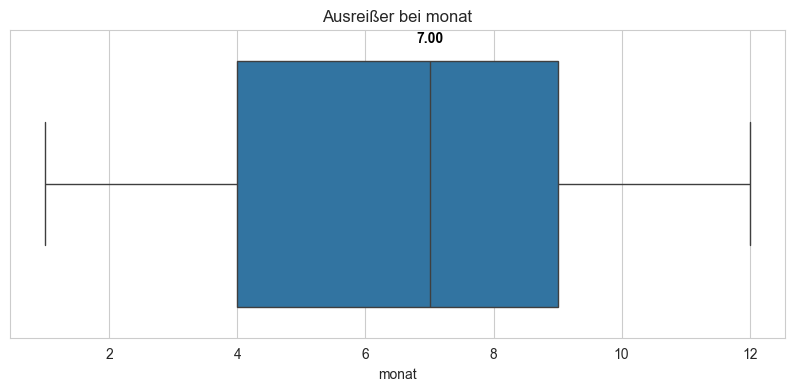

In [62]:
for column in numerical_columns:
    plt.figure(figsize=(10, 4))

    ax = sns.boxplot(x=df[column])

    median_line = ax.lines[4]
    x_coords = median_line.get_xdata()
    y_coords = median_line.get_ydata()

    median_val = x_coords[0]

    
    y_top = min(y_coords)  

    ax.text(
        x=median_val,
        y=y_top - 0.05, 
        s=f"{median_val:.2f}",
        color="black",
        weight="bold",
        ha="center",  
        va="bottom"  
    )

    plt.title(f"Ausreißer bei {column}")
    plt.show()

6. DATA VISUALIZATION  - KATEGORISCHE ANALYSE

6.1 Marken

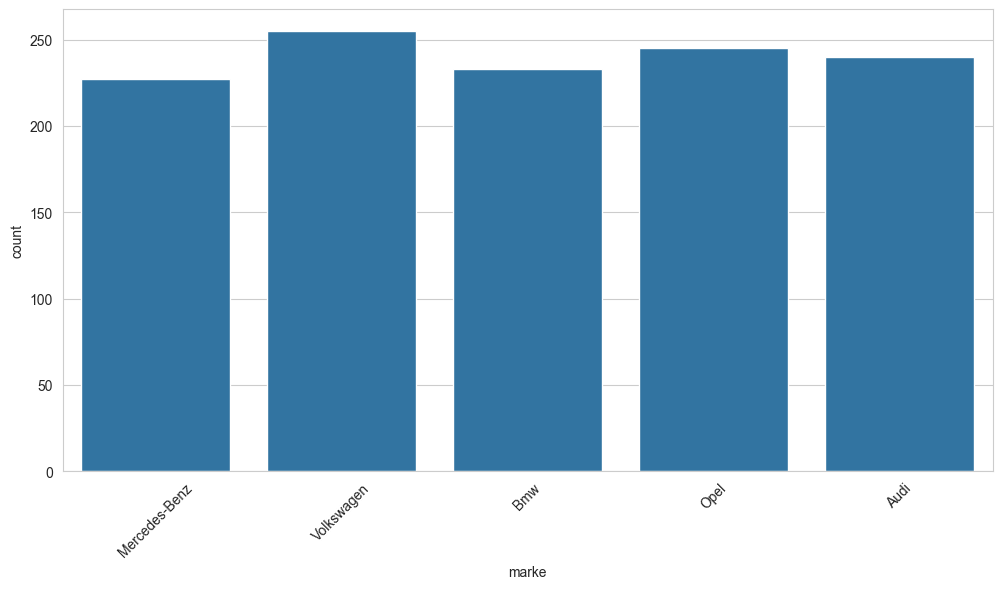

In [63]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="marke"
)

plt.xticks(rotation=45)

plt.show()

6.2 Kraftstoff

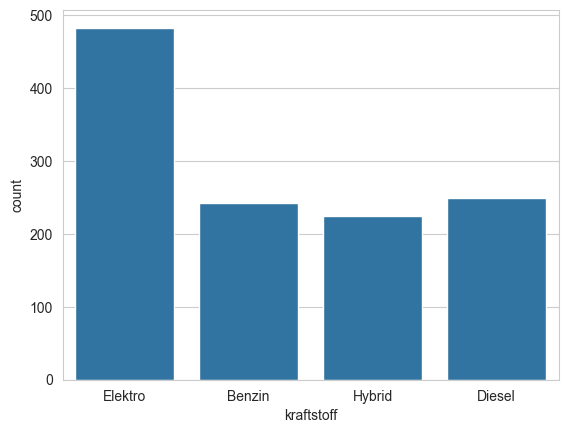

In [64]:
sns.countplot(
    data=df,
    x="kraftstoff"
)

plt.show()

6.3 Getriebe

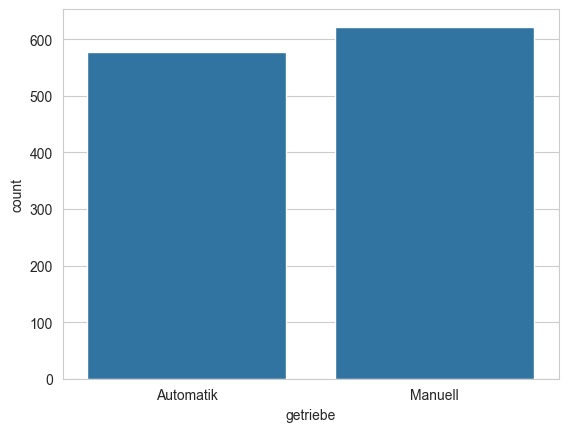

In [65]:
sns.countplot(
    data=df,
    x="getriebe"
)

plt.show()